In [2]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')

Saving archive (2).zip to archive (2).zip
User uploaded file "archive (2).zip" with length 16335 bytes


In [3]:
import zipfile
import os
zip_file_path = fn

extract_dir = 'extracted_data'
if not os.path.exists(extract_dir):
    os.makedirs(extract_dir)
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f"'{zip_file_path}' extracted to '{extract_dir}'")

'archive (2).zip' extracted to 'extracted_data'


In [4]:
import os
extracted_files = os.listdir(extract_dir)
print("Files extracted:")
for file_name in extracted_files:
    print(f"- {file_name}")

Files extracted:
- Unemployment_Rate_upto_11_2020.csv
- Unemployment in India.csv


In [5]:
import pandas as pd
file_india_path = os.path.join(extract_dir, 'Unemployment in India.csv')
df_india = pd.read_csv(file_india_path)

print("DataFrame: Unemployment in India.csv")
display(df_india.head())
df_india.info()

DataFrame: Unemployment in India.csv


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


In [6]:

file_rate_path = os.path.join(extract_dir, 'Unemployment_Rate_upto_11_2020.csv')
df_rate = pd.read_csv(file_rate_path)

print("\nDataFrame: Unemployment_Rate_upto_11_2020.csv")
display(df_rate.head())
df_rate.info()


DataFrame: Unemployment_Rate_upto_11_2020.csv


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 267 entries, 0 to 266
Data columns (total 9 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    267 non-null    object 
 1    Date                                     267 non-null    object 
 2    Frequency                                267 non-null    object 
 3    Estimated Unemployment Rate (%)          267 non-null    float64
 4    Estimated Employed                       267 non-null    int64  
 5    Estimated Labour Participation Rate (%)  267 non-null    float64
 6   Region.1                                  267 non-null    object 
 7   longitude                                 267 non-null    float64
 8   latitude                                  267 non-null    float64
dtypes: float64(4), int64(1), object(4)
memory usage: 18.9+ KB


In [7]:

df_combined = pd.concat([df_india, df_rate], ignore_index=True)

print("\nCombined DataFrame Head:")
display(df_combined.head())

print("\nCombined DataFrame Info:")
df_combined.info()

print(f"\nTotal rows in combined DataFrame: {len(df_combined)}")


Combined DataFrame Head:


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area,Region.1,longitude,latitude
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural,NaN,NaN,NaN
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural,NaN,NaN,NaN
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural,NaN,NaN,NaN
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural,NaN,NaN,NaN
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural,NaN,NaN,NaN



Combined DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1035 entries, 0 to 1034
Data columns (total 10 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    1007 non-null   object 
 1    Date                                     1007 non-null   object 
 2    Frequency                                1007 non-null   object 
 3    Estimated Unemployment Rate (%)          1007 non-null   float64
 4    Estimated Employed                       1007 non-null   float64
 5    Estimated Labour Participation Rate (%)  1007 non-null   float64
 6   Area                                      740 non-null    object 
 7   Region.1                                  267 non-null    object 
 8   longitude                                 267 non-null    float64
 9   latitude                                  267 non-null    float64
dtypes: float64

In [8]:
print("\nMissing values in combined DataFrame:")
display(df_combined.isnull().sum())


Missing values in combined DataFrame:


,0
Region,28
Date,28
Frequency,28
Estimated Unemployment Rate (%),28
Estimated Employed,28
Estimated Labour Participation Rate (%),28
Area,295
Region.1,768
longitude,768
latitude,768


In [9]:

df_combined.columns = df_combined.columns.str.strip()

core_columns = [
    'Region',
    'Date',
    'Frequency',
    'Estimated Unemployment Rate (%)',
    'Estimated Employed',
    'Estimated Labour Participation Rate (%)'
]
df_cleaned = df_combined.dropna(subset=core_columns).copy()

print(f"Original number of rows: {len(df_combined)}")
print(f"Number of rows after dropping NaNs in core columns: {len(df_cleaned)}")

print("\nMissing values after removing incomplete core records:")
display(df_cleaned.isnull().sum())

Original number of rows: 1035
Number of rows after dropping NaNs in core columns: 1007

Missing values after removing incomplete core records:


,0
Region,0
Date,0
Frequency,0
Estimated Unemployment Rate (%),0
Estimated Employed,0
Estimated Labour Participation Rate (%),0
Area,267
Region.1,740
longitude,740
latitude,740


In [10]:
df_final = df_cleaned.fillna(0).copy()

print(f"Number of rows in final DataFrame: {len(df_final)}")

print("\nMissing values after filling with 0:")
display(df_final.isnull().sum())

print("\nFinal DataFrame Info:")
df_final.info()

print("\nFinal DataFrame Head:")
display(df_final.head())

Number of rows in final DataFrame: 1007

Missing values after filling with 0:


,0
Region,0
Date,0
Frequency,0
Estimated Unemployment Rate (%),0
Estimated Employed,0
Estimated Labour Participation Rate (%),0
Area,0
Region.1,0
longitude,0
latitude,0



Final DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
Index: 1007 entries, 0 to 1034
Data columns (total 10 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Region                                   1007 non-null   object 
 1   Date                                     1007 non-null   object 
 2   Frequency                                1007 non-null   object 
 3   Estimated Unemployment Rate (%)          1007 non-null   float64
 4   Estimated Employed                       1007 non-null   float64
 5   Estimated Labour Participation Rate (%)  1007 non-null   float64
 6   Area                                     1007 non-null   object 
 7   Region.1                                 1007 non-null   object 
 8   longitude                                1007 non-null   float64
 9   latitude                                 1007 non-null   float64
dtypes: float64(5), object(5)
memor

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area,Region.1,longitude,latitude
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural,0,0.0,0.0
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural,0,0.0,0.0
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural,0,0.0,0.0
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural,0,0.0,0.0
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural,0,0.0,0.0


In [ ]:
display(df_final)

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area,Region.1,longitude,latitude
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural,0,0.0000,0.000
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural,0,0.0000,0.000
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural,0,0.0000,0.000
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural,0,0.0000,0.000
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural,0,0.0000,0.000
...,...,...,...,...,...,...,...,...,...,...
1030,West Bengal,30-06-2020,M,7.29,30726310.0,40.39,0,East,22.9868,87.855
1031,West Bengal,31-07-2020,M,6.83,35372506.0,46.17,0,East,22.9868,87.855
1032,West Bengal,31-08-2020,M,14.87,33298644.0,47.48,0,East,22.9868,87.855
1033,West Bengal,30-09-2020,M,9.35,35707239.0,47.73,0,East,22.9868,87.855


In [11]:
print(f"Shape of DataFrame before removing duplicates: {df_final.shape}")
duplicates_count = df_final.duplicated().sum()
print(f"Number of duplicate rows found: {duplicates_count}")

df_final = df_final.drop_duplicates().copy()
print(f"Shape of DataFrame after removing duplicates: {df_final.shape}")

Shape of DataFrame before removing duplicates: (1007, 10)
Number of duplicate rows found: 0
Shape of DataFrame after removing duplicates: (1007, 10)


In [ ]:
display(df_final)

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area,Region.1,longitude,latitude
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural,0,0.0000,0.000
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural,0,0.0000,0.000
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural,0,0.0000,0.000
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural,0,0.0000,0.000
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural,0,0.0000,0.000
...,...,...,...,...,...,...,...,...,...,...
1030,West Bengal,30-06-2020,M,7.29,30726310.0,40.39,0,East,22.9868,87.855
1031,West Bengal,31-07-2020,M,6.83,35372506.0,46.17,0,East,22.9868,87.855
1032,West Bengal,31-08-2020,M,14.87,33298644.0,47.48,0,East,22.9868,87.855
1033,West Bengal,30-09-2020,M,9.35,35707239.0,47.73,0,East,22.9868,87.855


In [12]:
df_final.columns = df_final.columns.str.strip()
df_final.columns = df_final.columns.str.replace(' ', '_').str.replace('%', 'percent').str.replace('(', '').str.replace(')', '')

print("Cleaned column names:")
print(df_final.columns)

Cleaned column names:
Index(['Region', 'Date', 'Frequency', 'Estimated_Unemployment_Rate_percent',
       'Estimated_Employed', 'Estimated_Labour_Participation_Rate_percent',
       'Area', 'Region.1', 'longitude', 'latitude'],
      dtype='object')


In [13]:
df_final['Date'] = pd.to_datetime(df_final['Date'], dayfirst=True)
df_final['Estimated_Employed'] = df_final['Estimated_Employed'].astype(int)

print("Data types after conversion:")
df_final.info()

Data types after conversion:
<class 'pandas.core.frame.DataFrame'>
Index: 1007 entries, 0 to 1034
Data columns (total 10 columns):
 #   Column                                       Non-Null Count  Dtype         
---  ------                                       --------------  -----         
 0   Region                                       1007 non-null   object        
 1   Date                                         1007 non-null   datetime64[ns]
 2   Frequency                                    1007 non-null   object        
 3   Estimated_Unemployment_Rate_percent          1007 non-null   float64       
 4   Estimated_Employed                           1007 non-null   int64         
 5   Estimated_Labour_Participation_Rate_percent  1007 non-null   float64       
 6   Area                                         1007 non-null   object        
 7   Region.1                                     1007 non-null   object        
 8   longitude                                    1007 non-

In [14]:
print("Unique values in 'Region':")
print(df_final['Region'].unique())

print("\nUnique values in 'Frequency':")
print(df_final['Frequency'].unique())

print("\nUnique values in 'Area':")
print(df_final['Area'].unique())

Unique values in 'Region':
['Andhra Pradesh' 'Assam' 'Bihar' 'Chhattisgarh' 'Delhi' 'Goa' 'Gujarat'
 'Haryana' 'Himachal Pradesh' 'Jammu & Kashmir' 'Jharkhand' 'Karnataka'
 'Kerala' 'Madhya Pradesh' 'Maharashtra' 'Meghalaya' 'Odisha' 'Puducherry'
 'Punjab' 'Rajasthan' 'Sikkim' 'Tamil Nadu' 'Telangana' 'Tripura'
 'Uttar Pradesh' 'Uttarakhand' 'West Bengal' 'Chandigarh']

Unique values in 'Frequency':
[' Monthly' 'Monthly' ' M']

Unique values in 'Area':
['Rural' 'Urban' 0]


In [15]:
display(df_final.describe())

,Date,Estimated_Unemployment_Rate_percent,Estimated_Employed,Estimated_Labour_Participation_Rate_percent,longitude,latitude
count,1007,1007.000000,1.007000e+03,1007.000000,1007.000000,1007.000000
mean,2020-01-31 06:06:04.647467776,11.906991,8.996209e+06,42.378620,6.052189,21.352689
min,2019-05-31 00:00:00,0.000000,4.942000e+04,13.330000,0.000000,0.000000
25%,2019-09-30 00:00:00,4.685000,1.639125e+06,37.835000,0.000000,0.000000
50%,2020-01-31 00:00:00,8.890000,5.543380e+06,40.880000,0.000000,0.000000
75%,2020-05-31 00:00:00,16.125000,1.287115e+07,45.315000,11.127100,74.124000
max,2020-10-31 00:00:00,76.740000,5.943376e+07,72.570000,33.778200,92.937600
std,NaN,10.739549,1.020784e+07,8.048542,10.583797,35.691667


In [16]:

print("Overall Unemployment Rate Statistics:")
print(df_final['Estimated_Unemployment_Rate_percent'].describe())
print("\nAverage Unemployment Rate by Region:")
display(df_final.groupby('Region')['Estimated_Unemployment_Rate_percent'].mean().sort_values(ascending=False))
print("\nAverage Unemployment Rate by Area:")
display(df_final.groupby('Area')['Estimated_Unemployment_Rate_percent'].mean())

Overall Unemployment Rate Statistics:
count    1007.000000
mean       11.906991
std        10.739549
min         0.000000
25%         4.685000
50%         8.890000
75%        16.125000
max        76.740000
Name: Estimated_Unemployment_Rate_percent, dtype: float64

Average Unemployment Rate by Region:


,Estimated_Unemployment_Rate_percent
Region,
Tripura,27.483158
Haryana,26.597368
Jharkhand,20.309737
Bihar,19.063684
Himachal Pradesh,17.888947
Delhi,17.000263
Jammu & Kashmir,16.275333
Chandigarh,15.991667
Rajasthan,14.534474



Average Unemployment Rate by Area:


,Estimated_Unemployment_Rate_percent
Area,
0,12.236929
Rural,10.324791
Urban,13.166614


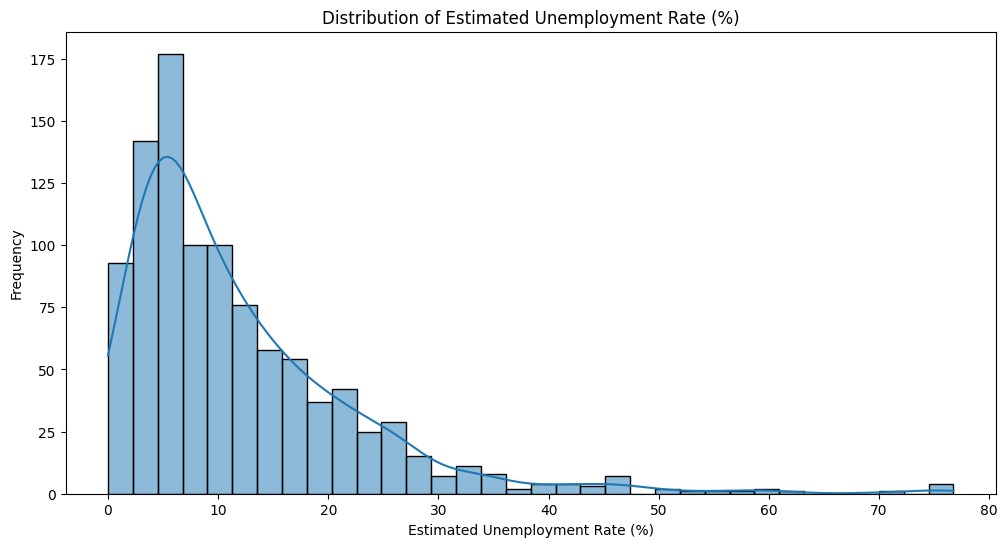

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.histplot(df_final['Estimated_Unemployment_Rate_percent'], kde=True)
plt.title('Distribution of Estimated Unemployment Rate (%)')
plt.xlabel('Estimated Unemployment Rate (%)')
plt.ylabel('Frequency')
plt.show()

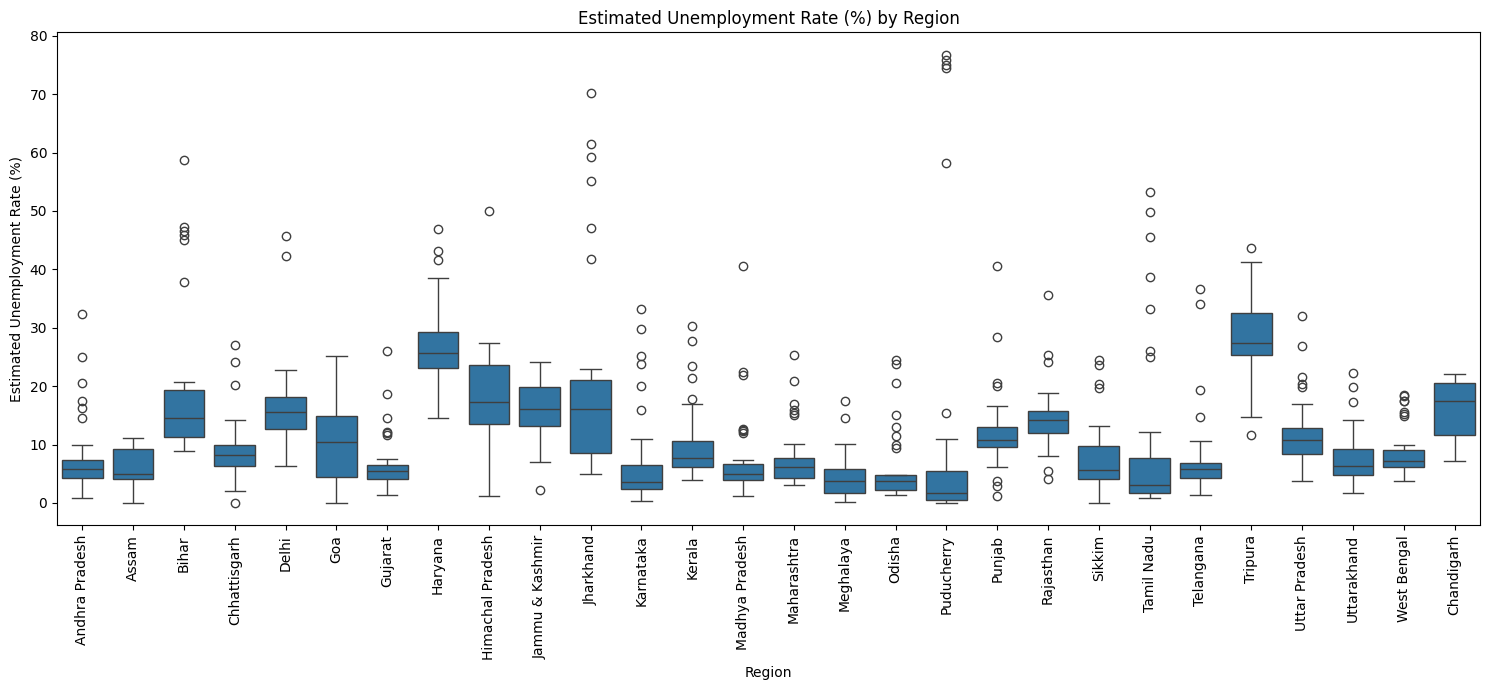

In [18]:
plt.figure(figsize=(15, 7))
sns.boxplot(x='Region', y='Estimated_Unemployment_Rate_percent', data=df_final)
plt.title('Estimated Unemployment Rate (%) by Region')
plt.xlabel('Region')
plt.ylabel('Estimated Unemployment Rate (%)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

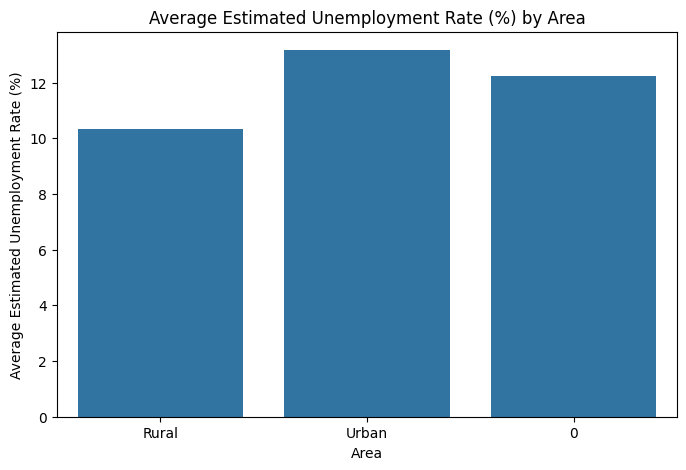

In [19]:
plt.figure(figsize=(8, 5))
sns.barplot(x='Area', y='Estimated_Unemployment_Rate_percent', data=df_final, errorbar=None)
plt.title('Average Estimated Unemployment Rate (%) by Area')
plt.xlabel('Area')
plt.ylabel('Average Estimated Unemployment Rate (%)')
plt.show()

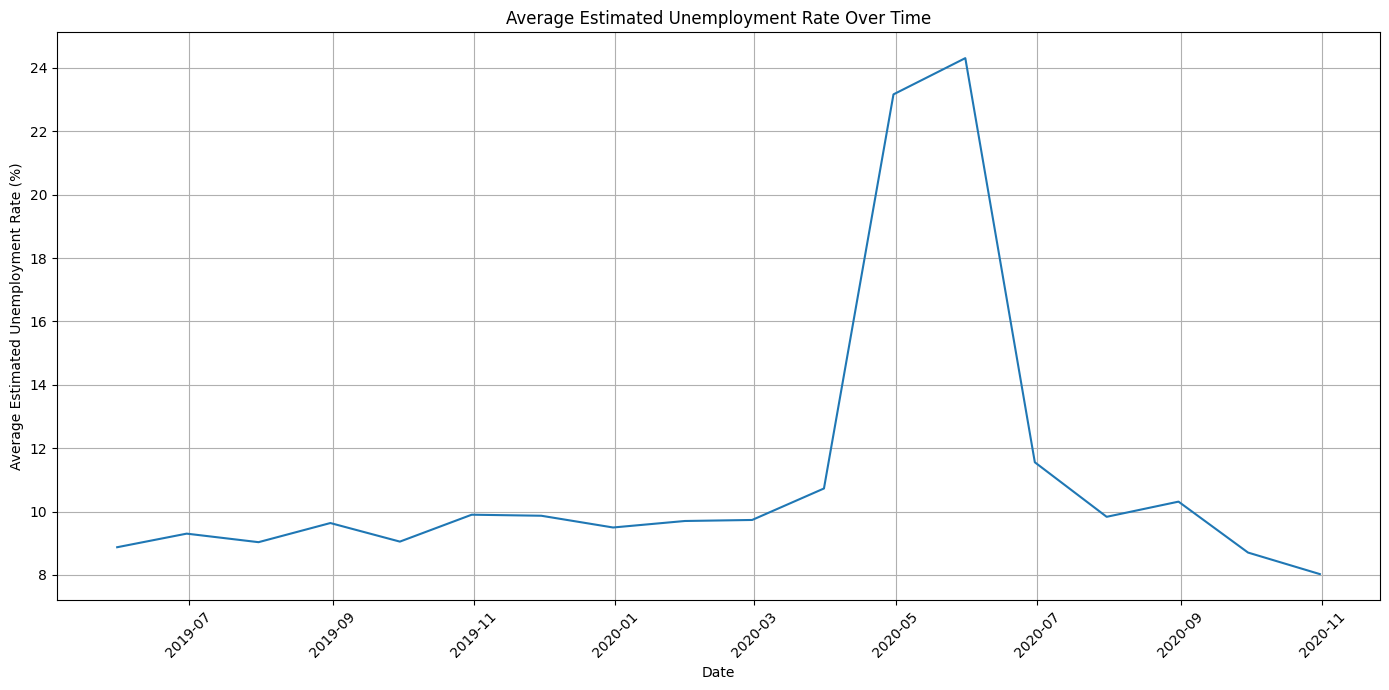

In [20]:

df_time_trend = df_final.groupby('Date')['Estimated_Unemployment_Rate_percent'].mean().reset_index()

plt.figure(figsize=(14, 7))
sns.lineplot(x='Date', y='Estimated_Unemployment_Rate_percent', data=df_time_trend)
plt.title('Average Estimated Unemployment Rate Over Time')
plt.xlabel('Date')
plt.ylabel('Average Estimated Unemployment Rate (%)')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/tmp/ipykernel_2942/2106547460.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Period', y='Estimated_Unemployment_Rate_percent', data=average_unemployment_by_period, palette='viridis')


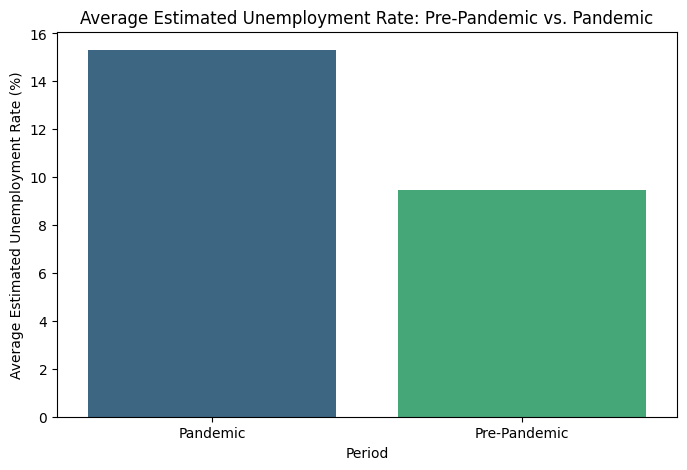


Average Unemployment Rate by Period:


,Period,Estimated_Unemployment_Rate_percent
0,Pandemic,15.305967
1,Pre-Pandemic,9.484932


In [21]:

pandemic_start_date = pd.to_datetime('2020-03-01')
df_final['Period'] = df_final['Date'].apply(lambda x: 'Pre-Pandemic' if x < pandemic_start_date else 'Pandemic')
average_unemployment_by_period = df_final.groupby('Period')['Estimated_Unemployment_Rate_percent'].mean().reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(x='Period', y='Estimated_Unemployment_Rate_percent', data=average_unemployment_by_period, palette='viridis')
plt.title('Average Estimated Unemployment Rate: Pre-Pandemic vs. Pandemic')
plt.xlabel('Period')
plt.ylabel('Average Estimated Unemployment Rate (%)')
plt.show()

print("\nAverage Unemployment Rate by Period:")
display(average_unemployment_by_period)

Let's further investigate the unemployment rates by region during the pandemic period to identify the most affected regions.

/tmp/ipykernel_2942/707356035.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Region', y='Estimated_Unemployment_Rate_percent', data=average_unemployment_pandemic_by_region, palette='magma')


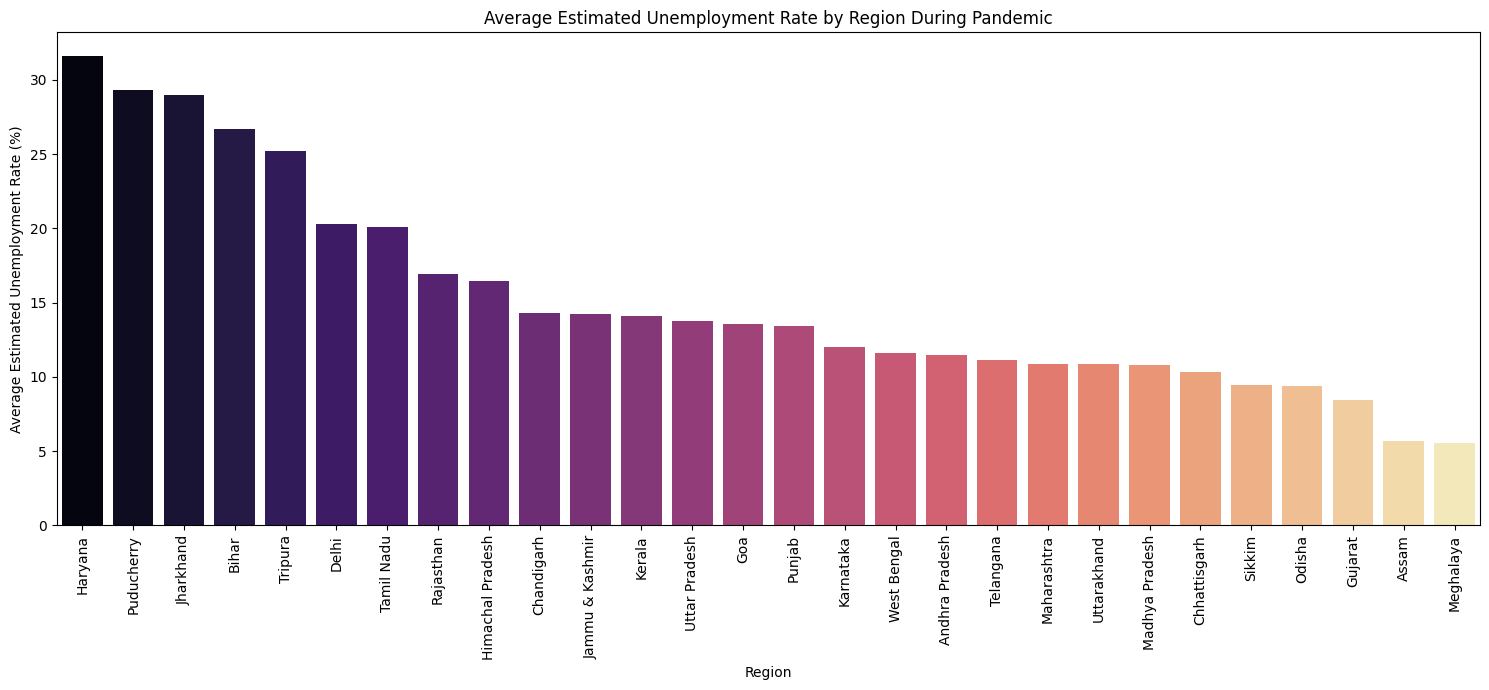


Top 10 Regions with Highest Average Unemployment Rate During Pandemic:


,Region,Estimated_Unemployment_Rate_percent
0,Haryana,31.617500
1,Puducherry,29.343571
2,Jharkhand,28.982500
3,Bihar,26.678750
4,Tripura,25.193750
5,Delhi,20.270625
6,Tamil Nadu,20.090000
7,Rajasthan,16.940000
8,Himachal Pradesh,16.470625
9,Chandigarh,14.325000


In [22]:

df_pandemic = df_final[df_final['Period'] == 'Pandemic']
average_unemployment_pandemic_by_region = df_pandemic.groupby('Region')['Estimated_Unemployment_Rate_percent'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(15, 7))
sns.barplot(x='Region', y='Estimated_Unemployment_Rate_percent', data=average_unemployment_pandemic_by_region, palette='magma')
plt.title('Average Estimated Unemployment Rate by Region During Pandemic')
plt.xlabel('Region')
plt.ylabel('Average Estimated Unemployment Rate (%)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

print("\nTop 10 Regions with Highest Average Unemployment Rate During Pandemic:")
display(average_unemployment_pandemic_by_region.head(10))

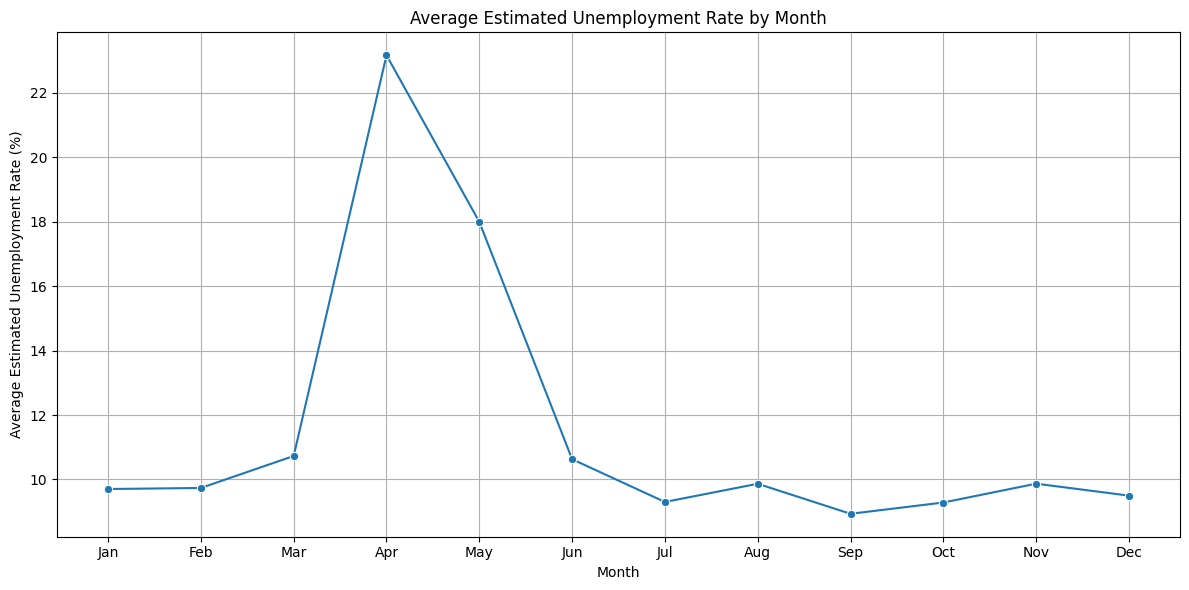


Average Unemployment Rate by Month:


,Month,Estimated_Unemployment_Rate_percent
0,1,9.702532
1,2,9.734810
2,3,10.728608
3,4,23.167013
4,5,17.995833
5,6,10.627176
6,7,9.300741
7,8,9.865875
8,9,8.933544
9,10,9.283659


In [23]:

df_final['Month'] = df_final['Date'].dt.month
average_unemployment_by_month = df_final.groupby('Month')['Estimated_Unemployment_Rate_percent'].mean().reset_index()
plt.figure(figsize=(12, 6))
sns.lineplot(x='Month', y='Estimated_Unemployment_Rate_percent', data=average_unemployment_by_month, marker='o')
plt.title('Average Estimated Unemployment Rate by Month')
plt.xlabel('Month')
plt.ylabel('Average Estimated Unemployment Rate (%)')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(True)
plt.tight_layout()
plt.show()

print("\nAverage Unemployment Rate by Month:")
display(average_unemployment_by_month)

In [24]:

Q1 = df_final['Estimated_Unemployment_Rate_percent'].quantile(0.25)
Q3 = df_final['Estimated_Unemployment_Rate_percent'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1: {Q1:.2f}")
print(f"Q3: {Q3:.2f}")
print(f"IQR: {IQR:.2f}")
print(f"Lower Bound for Outliers: {lower_bound:.2f}")
print(f"Upper Bound for Outliers: {upper_bound:.2f}")
outliers = df_final[(df_final['Estimated_Unemployment_Rate_percent'] < lower_bound) | (df_final['Estimated_Unemployment_Rate_percent'] > upper_bound)]
print(f"\nNumber of outliers detected: {len(outliers)}")
df_no_outliers = df_final[~((df_final['Estimated_Unemployment_Rate_percent'] < lower_bound) | (df_final['Estimated_Unemployment_Rate_percent'] > upper_bound))].copy()

print(f"Number of rows before outlier removal: {len(df_final)}")
print(f"Number of rows after outlier removal: {len(df_no_outliers)}")
print("\nDescriptive statistics for 'Estimated_Unemployment_Rate_percent' after outlier removal:")
display(df_no_outliers['Estimated_Unemployment_Rate_percent'].describe())

Q1: 4.69
Q3: 16.12
IQR: 11.44
Lower Bound for Outliers: -12.47
Upper Bound for Outliers: 33.28

Number of outliers detected: 45
Number of rows before outlier removal: 1007
Number of rows after outlier removal: 962

Descriptive statistics for 'Estimated_Unemployment_Rate_percent' after outlier removal:


,Estimated_Unemployment_Rate_percent
count,962.000000
mean,10.295707
std,7.433586
min,0.000000
25%,4.572500
50%,8.185000
75%,14.812500
max,33.170000


Based on our comprehensive analysis, here are some key insights that could inform economic and social policies:

Insights for Economic and Social Policies
Regional Disparities: We observed significant differences in unemployment rates across regions, both generally and specifically during the pandemic. For instance, Haryana, Puducherry, and Jharkhand experienced the highest average unemployment rates during the pandemic. This suggests a need for:

Targeted Regional Development Programs: Policies should focus on creating employment opportunities and skill development in consistently high-unemployment regions.
Infrastructure Investment: Improve infrastructure in these regions to attract industries and foster economic growth.
Impact of Crises (e.g., COVID-19): The average unemployment rate significantly increased during the pandemic period compared to pre-pandemic times. This highlights the vulnerability of the labor market to external shocks and the need for:

Robust Social Safety Nets: Strengthen unemployment benefits and social assistance programs to support individuals during economic downturns or crises.
Economic Diversification: Encourage diversification of regional economies to reduce reliance on sectors most vulnerable to crises.
Emergency Job Creation Schemes: Implement temporary public works or job retention schemes during crises to mitigate job losses.
Urban vs. Rural Dynamics: We analyzed unemployment rates in rural and urban areas. Understanding these differences can lead to:

Rural Employment Initiatives: Promote agricultural diversification, rural entrepreneurship, and non-farm employment opportunities.
Urban Skill Development: Align urban vocational training programs with industry demands to address specific skill gaps.
Seasonal Trends: The analysis of average unemployment rates by month revealed potential seasonal patterns. For example, unemployment peaked in April and May. This indicates a need for:

Seasonal Employment Support: Implement policies that provide temporary support or alternative employment during off-peak seasons for workers in seasonal industries.
Skill Training for Off-Season: Offer training programs that allow seasonal workers to acquire skills for employment during their off-season.
Labor Participation: Understanding estimated labor participation rates is crucial. Policies should aim to:

Promote Workforce Participation: Address barriers to labor force entry for certain demographics (e.g., women, youth) through education, childcare support, and flexible work arrangements.
Invest in Education and Training: Ensure the workforce has the necessary skills for the evolving job market to boost participation and employability.